
First five data
   age  gender  daily_social_media_hours platform_usage  sleep_hours  \
0   14    male                       7.9      Instagram          7.4   
1   19  female                       1.9         TikTok          8.0   
2   17  female                       1.3      Instagram          7.6   
3   15    male                       7.4         TikTok          6.9   
4   15  female                       4.7           Both          4.9   

   screen_time_before_sleep  academic_performance  physical_activity  \
0                       2.9                  3.01                1.5   
1                       2.9                  3.22                0.8   
2                       0.5                  3.92                0.0   
3                       1.6                  3.48                0.8   
4                       3.0                  2.37                1.4   

  social_interaction_level  stress_level  anxiety_level  addiction_level  \
0                      low             2 

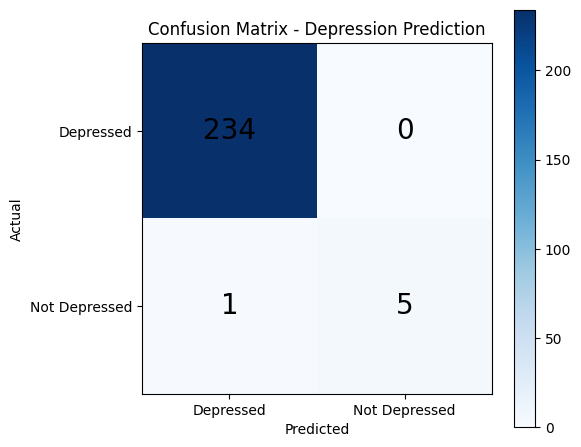

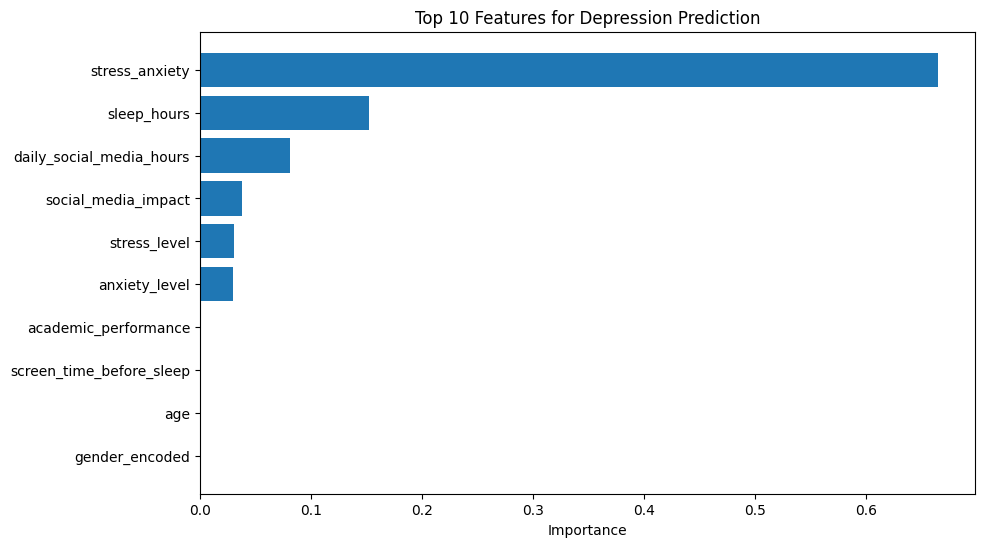

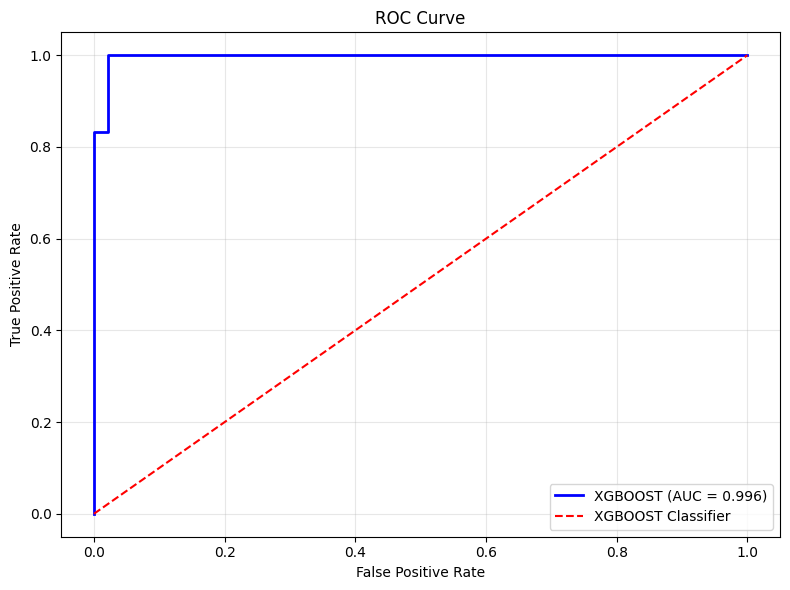

In [8]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, confusion_matrix
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns

# Load data
data = pd.read_csv("Teen_Mental_Health_Dataset.csv")
print("\nFirst five data")
print(data.head())
print("\nData Description")
print(data.describe())

# Check for missing values
print("\nmissing values")
print(data.isnull().sum())

# Check class distribution
print(data['depression_label'].value_counts())
print(f"Depression rate: {data['depression_label'].mean():.3%}")


# Calculate class weights
classes = np.unique(data['depression_label'])
weights = compute_class_weight('balanced', classes=classes, y=data['depression_label'])
class_weight_dict = dict(zip(classes, weights))
print(f"Class weights: {class_weight_dict}")
# Will give high weight to class 1 (depression)

# Create interaction features (social media impact)
data['social_media_impact'] = (data['daily_social_media_hours'] * 
                               data['addiction_level']) / 10

# Sleep deprivation indicator
data['sleep_deprived'] = (data['sleep_hours'] < 6).astype(int)

# High stress + anxiety combined
data['stress_anxiety'] = (data['stress_level'] + data['anxiety_level']) / 2

# Screen time before sleep risk
data['screen_risk'] = (data['screen_time_before_sleep'] > 2).astype(int)

# Physical activity deficiency
data['inactive'] = (data['physical_activity'] == 0).astype(int)

# Academic pressure (higher performance might mean less time for socials?)
# But here, low academic performance might correlate with depression
data['academic_struggle'] = (data['academic_performance'] < 2.5).astype(int)

# Platform risk (based on your data patterns)
# TikTok and Both might be higher risk
platform_risk = {'TikTok': 2, 'Instagram': 1, 'Both': 3, 'Snapchat': 1, 'YouTube': 0}
data['platform_risk_score'] = data['platform_usage'].map(platform_risk)




# Encode gender
le_gender = LabelEncoder()
data['gender_encoded'] = le_gender.fit_transform(data['gender'])

# Encode platform usage
le_platform = LabelEncoder()
data['platform_encoded'] = le_platform.fit_transform(data['platform_usage'])

# Encode social_interaction_level
interaction_map = {'low': 0, 'medium': 1, 'high': 2}
data['interaction_encoded'] = data['social_interaction_level'].map(interaction_map)

# Select features for modeling
feature_cols = ['age', 'gender_encoded', 'daily_social_media_hours', 
                'platform_encoded', 'sleep_hours', 'screen_time_before_sleep',
                'academic_performance', 'physical_activity', 'interaction_encoded',
                'stress_level', 'anxiety_level', 'addiction_level',
                'social_media_impact', 'sleep_deprived', 'stress_anxiety',
                'platform_risk_score']

X = data[feature_cols]
y = data['depression_label']


# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# CROSS VALIDATION
# Initialize Stratified K-Fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize model
model = XGBClassifier(
    scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),
    n_estimators=100,
    random_state=42,
    eval_metric='logloss'
)


# Cross-validate on TRAIN data only
cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1_macro')

print(f"Stratified 5-Fold CV Results:")
print(f"F1 scores per fold: {cv_scores}")
print(f"Mean F1: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

print("\nTraining" +"\n" + "="*60)
model = XGBClassifier(
    scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),
    n_estimators=100,
    random_state=42
)

      
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred_train = model.predict(X_train)

# Evaluation
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_pred)

print(f"F1_score: {f1:.4f}")
print(f"ROC_AUC_score: {roc:.4f}")

print("\n" + "=" * 60)
print("TOP 10 MOST IMPORTANT FEATURES")
print("=" * 60)
feature_importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

print(feature_importance_df)

    
def plot_confusion_matrix(y_true, y_pred, class_names=[0, 1]):
    cm = confusion_matrix(y_test, y_pred)
    # Print interpretation
    print("\nConfusion Matrix Interpretation:")
    print(f"True Negatives (correctly predicted Class 0): {cm[0,0]}")
    print(f"False Positives (predicted Class 1, actual Class 0): {cm[0,1]}")
    print(f"False Negatives (predicted Class 0, actual Class 1): {cm[1,0]}")
    print(f"True Positives (correctly predicted Class 1): {cm[1,1]}")

    # Create plot
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.colorbar()

    # Labels
    tick_marks = [0, 1]
    plt.xticks(tick_marks, ["Depressed", "Not Depressed"])
    plt.yticks(tick_marks, ["Depressed", "Not Depressed"])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix - Depression Prediction')

    # Add numbers inside boxes
    for i in range(2):
        for j in range(2):
            plt.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=20)

    plt.tight_layout()
    plt.show()

# feature importance
def plot_feature_importance(feature_names):
   
    plt.figure(figsize=(10, 6))
    
    importance = model.feature_importances_
    sorted_idx = np.argsort(importance)[::-1][:10]
    plt.barh([feature_cols[i] for i in sorted_idx], importance[sorted_idx])
    plt.gca().invert_yaxis()
    plt.xlabel('Importance')
    plt.title('Top 10 Features for Depression Prediction')
    

# ROC CURVE
def plot_roc_curve(model, X_test, y_test):
    """
    Plot ROC curve and calculate AUC
    """
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'XGBOOST (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], 'r--', label='XGBOOST Classifier')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()



plot_confusion_matrix(y_test, y_pred, class_names=["Depressed", "Not Depressed"])
plot_feature_importance(feature_cols)
plot_roc_curve(model, X_test, y_test)